# 00 — Ballot support context

## Purpose

This notebook is **context for our finance analysis**, not a new standalone
ballot-support research project.

The ballot-support metrics used here (`mentions`, `first_place_votes`,
`stv_threshold`, `is_viable`) come from the prior Data and Democracy Lab
Portland STV report / VoteKit reconstruction. We treat them as **given
inputs** and reproduce two of the report's district-level figures, so this
topic has its own baseline before we relate it to campaign finance.

This notebook does **not** re-derive anything from VoteKit. It only reads
the canonical processed table.

## 1. Load data

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Find the repository root by walking upward until we find pyproject.toml.
# This works no matter how many folders deep the notebook lives.
ROOT = Path.cwd().resolve()

while not (ROOT / "pyproject.toml").exists():
    if ROOT == ROOT.parent:
        raise FileNotFoundError(
            "Could not find repository root. "
            "Expected a pyproject.toml file somewhere above this notebook."
        )
    ROOT = ROOT.parent

print("ROOT:", ROOT)

YEAR = 2024

BALLOT_SUPPORT_PATH = (
    ROOT
    / "data"
    / "processed"
    / "ballot_support"
    / str(YEAR)
    / f"candidate_ballot_support_{YEAR}.csv"
)

FIGURES_DIR = ROOT / "finance_vs_ballot_support" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Ballot support path exists:", BALLOT_SUPPORT_PATH.exists())

ROOT: /Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis
Ballot support path exists: True


In [2]:
ballot = pd.read_csv(BALLOT_SUPPORT_PATH)

print("Rows:", len(ballot))
print("Candidates by district:")
display(ballot["district"].value_counts().sort_index())

ballot.head()

Rows: 98
Candidates by district:


district
1    16
2    22
3    30
4    30
Name: count, dtype: int64

,year,district,source_candidate_name,mentions,mention_share,first_place_votes,first_place_share,total_ballot_weight,stv_threshold,is_viable,canonical_candidate,candidate_key
0,2024,1,Timur Ender,16858.0,0.393226,3550.0,0.082807,42871.0,10718.0,True,Timur Ender,2024|1|timur ender
1,2024,1,Terrence Hayes,15967.0,0.372443,3975.0,0.092720,42871.0,10718.0,True,Terrence Hayes,2024|1|terrence hayes
2,2024,1,Loretta Smith,17984.0,0.419491,5586.0,0.130298,42871.0,10718.0,True,Loretta Smith,2024|1|loretta smith
3,2024,1,Deian Salazar,5262.0,0.122740,720.0,0.016795,42871.0,10718.0,False,Deian Salazar,2024|1|deian salazar
4,2024,1,Joe Allen,4955.0,0.115579,978.0,0.022813,42871.0,10718.0,False,Joe Allen,2024|1|joe allen


## 2. Reproduce the prior report's Figure 2

For each district, candidates are ordered by `mentions` (descending).

- light bar = `mentions`
- dark bar = `first_place_votes`
- red dashed line = that district's `stv_threshold`

Candidate names don't fit on the x-axis when a district has 20-30
candidates, so we number the bars and list names in a small box next to
each panel — the same approach the report uses.

In [3]:
def plot_support_by_district(
    df,
    mentions_col,
    first_place_col,
    y_label,
    threshold_col=None,
    threshold_value=None,
    title=None,
):
    """One stacked panel per district: mentions + first-place bars + threshold line.

    Pass either `threshold_col` (a column with each district's own threshold,
    e.g. "stv_threshold") or a fixed `threshold_value` (e.g. 100 for the
    percent-of-threshold version).
    """

    districts = sorted(df["district"].unique())

    fig, axes = plt.subplots(
        len(districts),
        1,
        figsize=(10, 5.5 * len(districts)),
    )

    for ax, district in zip(axes, districts):
        district_data = (
            df[df["district"] == district]
            .sort_values(mentions_col, ascending=False)
            .reset_index(drop=True)
        )

        x = range(1, len(district_data) + 1)

        ax.bar(x, district_data[mentions_col], color="skyblue", label="Mentions")
        ax.bar(x, district_data[first_place_col], color="navy", label="First place votes")

        if threshold_col is not None:
            line_value = district_data[threshold_col].iloc[0]
            line_label = f"Threshold: {line_value:,.0f}"
        else:
            line_value = threshold_value
            line_label = f"Threshold: {line_value:,.0f}%"

        ax.axhline(line_value, color="red", linestyle="--", label=line_label)

        ax.set_xticks(list(x))
        ax.set_xlabel("Candidates in order of mentions")
        ax.set_ylabel(y_label)
        ax.set_title(f"District {district}")
        ax.legend(loc="upper right", fontsize=8)

        # Small numbered legend so candidate names stay readable.
        name_list = "\n".join(
            f"{i} - {name}"
            for i, name in zip(x, district_data["canonical_candidate"])
        )

        ax.text(
            1.02,
            1.0,
            name_list,
            transform=ax.transAxes,
            fontsize=7,
            va="top",
            ha="left",
            bbox={"boxstyle": "round", "facecolor": "white", "edgecolor": "gray"},
        )

    if title:
        fig.suptitle(title, y=1.0, fontsize=13)

    plt.tight_layout(rect=[0, 0, 0.8, 0.98])

    return fig

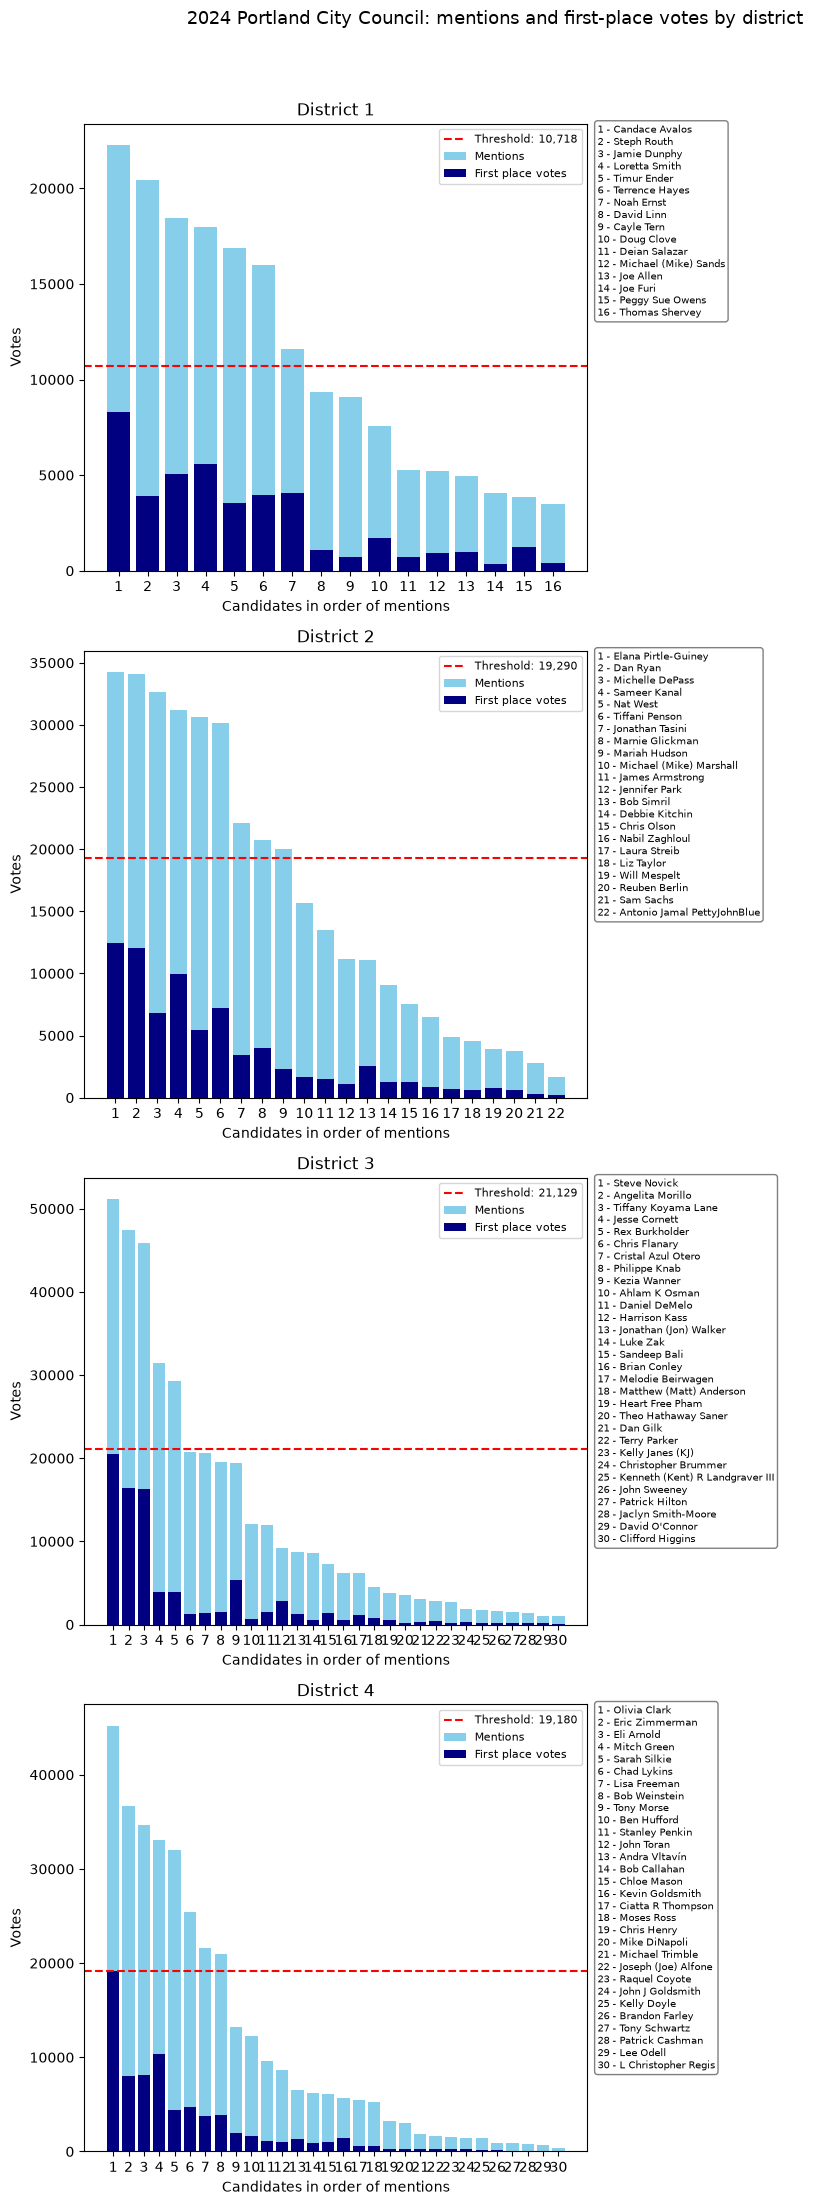

Saved: /Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis/finance_vs_ballot_support/figures/candidate_support_by_district.png


In [4]:
fig_counts = plot_support_by_district(
    ballot,
    mentions_col="mentions",
    first_place_col="first_place_votes",
    y_label="Votes",
    threshold_col="stv_threshold",
    title="2024 Portland City Council: mentions and first-place votes by district",
)

plt.show()

fig_counts.savefig(
    FIGURES_DIR / "candidate_support_by_district.png",
    dpi=150,
    bbox_inches="tight",
)

print("Saved:", FIGURES_DIR / "candidate_support_by_district.png")

## 3. Support relative to threshold

Districts have different STV thresholds, so raw vote counts aren't directly
comparable across districts. We express support as a percent of each
candidate's own district threshold:

```python
ballot["mentions_pct_threshold"] = (
    100 * ballot["mentions"] / ballot["stv_threshold"]
)

ballot["first_place_pct_threshold"] = (
    100 * ballot["first_place_votes"] / ballot["stv_threshold"]
)
```

**100% = the STV election threshold for that candidate's district.**

- 150% = mentions equal to 1.5 times the district threshold
- 80% = mentions equal to 0.8 times the district threshold

This normalization makes support more comparable across districts with
different thresholds. We don't save this as a new CSV — it's a simple
derived metric, recreated here whenever it's needed.

In [5]:
ballot["mentions_pct_threshold"] = (
    100 * ballot["mentions"] / ballot["stv_threshold"]
)

ballot["first_place_pct_threshold"] = (
    100 * ballot["first_place_votes"] / ballot["stv_threshold"]
)

ballot[
    [
        "district",
        "canonical_candidate",
        "mentions",
        "stv_threshold",
        "mentions_pct_threshold",
        "is_viable",
    ]
].sort_values(["district", "mentions_pct_threshold"], ascending=[True, False]).head(10)

,district,canonical_candidate,mentions,stv_threshold,mentions_pct_threshold,is_viable
14,1,Candace Avalos,22267.0,10718.0,207.753312,True
13,1,Steph Routh,20440.0,10718.0,190.707221,True
6,1,Jamie Dunphy,18470.0,10718.0,172.326927,True
2,1,Loretta Smith,17984.0,10718.0,167.792499,True
0,1,Timur Ender,16858.0,10718.0,157.286807,True
1,1,Terrence Hayes,15967.0,10718.0,148.973689,True
5,1,Noah Ernst,11606.0,10718.0,108.285128,True
15,1,David Linn,9324.0,10718.0,86.993842,False
11,1,Cayle Tern,9061.0,10718.0,84.540026,False
7,1,Doug Clove,7593.0,10718.0,70.843441,False


## 4. Reproduce the figure using % of threshold

Same layout as Section 2, but using the normalized columns. The threshold
line is now always at **100%** in every district.

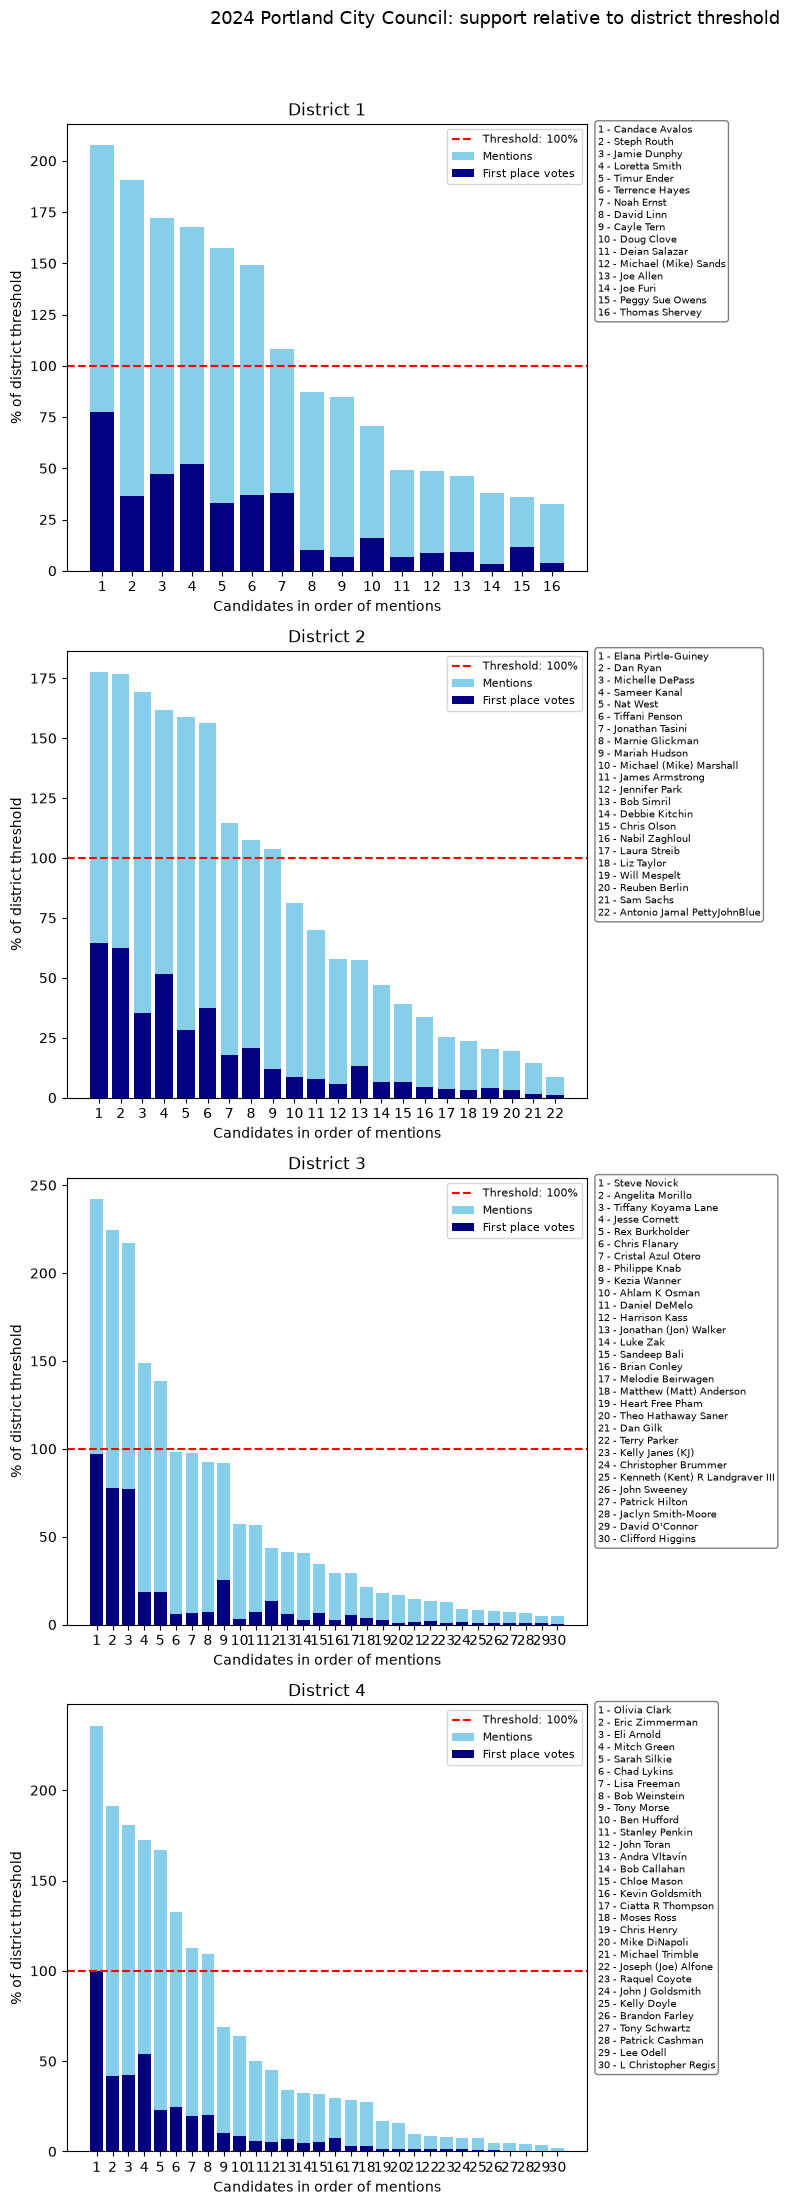

Saved: /Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis/finance_vs_ballot_support/figures/candidate_support_relative_to_threshold.png


In [6]:
fig_pct = plot_support_by_district(
    ballot,
    mentions_col="mentions_pct_threshold",
    first_place_col="first_place_pct_threshold",
    y_label="% of district threshold",
    threshold_value=100,
    title="2024 Portland City Council: support relative to district threshold",
)

plt.show()

fig_pct.savefig(
    FIGURES_DIR / "candidate_support_relative_to_threshold.png",
    dpi=150,
    bbox_inches="tight",
)

print("Saved:", FIGURES_DIR / "candidate_support_relative_to_threshold.png")